# CAPSTONE PROJECT DATA SCIENCE — DBS CODING CAMP 2026

## 1. Problem Discovery

### Latar Belakang
Kesehatan mental menjadi isu kritis di era digital. Menurut WHO, lebih dari 280 juta orang mengalami depresi secara global. Aplikasi **Daylio** memungkinkan pengguna mencatat mood harian beserta aktivitas, namun data tersebut belum diolah untuk menghasilkan insight.

### Permasalahan
1. Data mood tracker masih mentah dan belum siap untuk diproses model AI.
2. Belum ada analisis yang mengungkap hubungan aktivitas dengan mood.
3. Belum tersedia dataset bersih yang terklasifikasi berdasarkan sentimen untuk keperluan machine learning.

### Solusi
Melakukan **pipeline Data Science end-to-end**: membersihkan data, menganalisis pola, melakukan feature engineering, dan mengekspor dataset bersih **terklasifikasi per sentimen** (Positif, Netral, Negatif) agar siap diproses oleh AI Engineer untuk membangun model prediksi mood.

### Dataset
- **Sumber**: [Kaggle — Daylio Mood Tracker](https://www.kaggle.com/datasets/kingabzpro/daylio-mood-tracker)
- **Ukuran**: 940 entri

## Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json, os, warnings
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print(" Library berhasil diimport!")

 Library berhasil diimport!


# 2. Data Wrangling

## 2.1 Gathering Data
Dataset diunduh dari Kaggle (sumber publik) berisi catatan mood harian pengguna aplikasi Daylio.

In [2]:
# Gathering: load dataset
if os.path.exists('/content/Dataset_FIX.csv'):
    df = pd.read_csv('/content/Dataset_FIX.csv')
else:
    df = pd.read_csv('Dataset_FIX.csv')

print(f" Dataset dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")
df.head()

 Dataset dimuat: 1200 baris × 8 kolom


,tanggal_lengkap,tanggal,hari,waktu,sub_suasana_hati,aktivitas,suasana_hati,sentimen
0,07/10/2020,Oct-07,Rabu,9:11 pm,bingung,Belajar | Seni | Berdoa | Berpuasa | Membaca Q...,Biasa,Netral
1,25/10/2018,Oct-25,Kamis,10:03 am,bertanya-tanya,Berita Terkini | Sahabat Pena,Biasa,Netral
2,04/05/2019,May-04,Sabtu,10:15 am,tersulut emosi,Dota 2 | Podcast | Buku Audio | Berita Terkini...,Sangat Buruk,Negatif
3,03/03/2018,Mar-03,Sabtu,2:00 pm,keren,Streaming | YouTube | Penelitian | Hal Baru | ...,Luar Biasa,Positif
4,07/08/2020,Aug-07,Jumat,7:19 am,marah,Membaca | Belajar | Seni | Berdoa | Berpuasa |...,Sangat Buruk,Negatif


## Data Dictionary

| No | Kolom | Tipe | Deskripsi |
|----|-------|------|-----------|
| 1 | `full_date` | object → datetime | Tanggal pencatatan |
| 2 | `date` | object | Format singkat tanggal |
| 3 | `weekday` | object | Hari dalam seminggu |
| 4 | `time` | object | Waktu pencatatan |
| 5 | `sub_mood` | object | Emosi spesifik (sub-kategori mood) |
| 6 | `activities` | object | Daftar aktivitas (pipe-separated) |
| 7 | `mood` | object | **Label klasifikasi**: Awful / Bad / Normal / Good / Amazing |

## 2.2 Assessing Data

In [3]:
# Struktur data
print(" INFO DATASET")
df.info()

 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal_lengkap   1200 non-null   object
 1   tanggal           1200 non-null   object
 2   hari              1200 non-null   object
 3   waktu             1200 non-null   object
 4   sub_suasana_hati  1200 non-null   object
 5   aktivitas         1106 non-null   object
 6   suasana_hati      1200 non-null   object
 7   sentimen          1200 non-null   object
dtypes: object(8)
memory usage: 75.1+ KB


In [4]:
# Missing values
print("\n MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Pct(%)': missing_pct}))


 MISSING VALUES
                  Count  Pct(%)
tanggal_lengkap       0    0.00
tanggal               0    0.00
hari                  0    0.00
waktu                 0    0.00
sub_suasana_hati      0    0.00
aktivitas            94    7.83
suasana_hati          0    0.00
sentimen              0    0.00


In [5]:
# Duplikasi
print(f"\n DUPLIKASI: {df.duplicated().sum()} baris")


 DUPLIKASI: 630 baris


In [6]:
# Distribusi mood (label asli)
print("\n DISTRIBUSI LABEL MOOD (asli)")
print(df['suasana_hati'].value_counts())


 DISTRIBUSI LABEL MOOD (asli)
suasana_hati
Biasa           400
Buruk           214
Luar Biasa      207
Baik            193
Sangat Buruk    186
Name: count, dtype: int64


### Temuan Assessing
| Temuan | Tindakan |
|--------|----------|
| 47 missing values di `activities` | Drop baris |
| Semua kolom bertipe object | Konversi `full_date` ke datetime |
| Spasi berlebih di beberapa nilai | Strip whitespace |
| Aktivitas dalam format pipe-separated | Split menjadi list, lalu explode |
| Mood 5 kelas perlu dikelompokkan | Mapping ke 3 sentimen (Positif/Netral/Negatif) |

## 2.3 Cleaning Data

In [7]:
# STEP 1: Drop missing values
print(f"Sebelum: {len(df)} baris")
df = df.dropna(subset=['aktivitas'])
print(f"Setelah drop null aktivitas: {len(df)} baris")

# STEP 2: Strip whitespace
df['suasana_hati'] = df['suasana_hati'].str.strip()
df['sub_suasana_hati'] = df['sub_suasana_hati'].str.strip()
df['aktivitas'] = df['aktivitas'].str.strip()
df['sentimen'] = df['sentimen'].str.strip()
print(" Whitespace dibersihkan")

# STEP 3: Gunakan kolom sentimen yang sudah ada sebagai label mood
df['mood'] = df['sentimen']
print(" Kolom sentimen digunakan langsung sebagai label mood")
print(df['mood'].value_counts())

# STEP 4: Konversi tanggal
df['tanggal_lengkap'] = pd.to_datetime(df['tanggal_lengkap'], format='%d/%m/%Y')
print(" tanggal_lengkap dikonversi ke datetime")

# STEP 5: Parse hour dari waktu
def parse_hour(t):
    try:
        parts = t.strip().split()
        hour = int(parts[0].split(':')[0])
        if parts[1].lower() == 'pm' and hour != 12: hour += 12
        elif parts[1].lower() == 'am' and hour == 12: hour = 0
        return hour
    except:
        return None

df['hour'] = df['waktu'].apply(parse_hour)
print(" Kolom hour ditambahkan")

# STEP 6: Split aktivitas → list
df['activities_list'] = df['aktivitas'].apply(
    lambda x: [a.strip() for a in str(x).split('|') if a.strip()]
)
df_exploded = df.explode('activities_list')
df_exploded = df_exploded[df_exploded['activities_list'] != '']
print(f" Aktivitas di-split: {df_exploded['activities_list'].nunique()} aktivitas unik")

# Verifikasi
print(f"\n Data bersih: {len(df)} baris, missing: {df.isnull().sum().sum()}")
df.head()


Sebelum: 1200 baris
Setelah drop null aktivitas: 1106 baris
 Whitespace dibersihkan
 Kolom sentimen digunakan langsung sebagai label mood
mood
Positif    389
Negatif    368
Netral     349
Name: count, dtype: int64
 tanggal_lengkap dikonversi ke datetime
 Kolom hour ditambahkan
 Aktivitas di-split: 57 aktivitas unik

 Data bersih: 1106 baris, missing: 0


,tanggal_lengkap,tanggal,hari,waktu,sub_suasana_hati,aktivitas,suasana_hati,sentimen,mood,hour,activities_list
0,2020-10-07,Oct-07,Rabu,9:11 pm,bingung,Belajar | Seni | Berdoa | Berpuasa | Membaca Q...,Biasa,Netral,Netral,21,"[Belajar, Seni, Berdoa, Berpuasa, Membaca Qura..."
1,2018-10-25,Oct-25,Kamis,10:03 am,bertanya-tanya,Berita Terkini | Sahabat Pena,Biasa,Netral,Netral,10,"[Berita Terkini, Sahabat Pena]"
2,2019-05-04,May-04,Sabtu,10:15 am,tersulut emosi,Dota 2 | Podcast | Buku Audio | Berita Terkini...,Sangat Buruk,Negatif,Negatif,10,"[Dota 2, Podcast, Buku Audio, Berita Terkini, ..."
3,2018-03-03,Mar-03,Sabtu,2:00 pm,keren,Streaming | YouTube | Penelitian | Hal Baru | ...,Luar Biasa,Positif,Positif,14,"[Streaming, YouTube, Penelitian, Hal Baru, Sur..."
4,2020-08-07,Aug-07,Jumat,7:19 am,marah,Membaca | Belajar | Seni | Berdoa | Berpuasa |...,Sangat Buruk,Negatif,Negatif,7,"[Membaca, Belajar, Seni, Berdoa, Berpuasa, Mem..."


# 3. Pertanyaan Bisnis

1. **Bagaimana distribusi sentimen pengguna?** Sentimen mana yang dominan?
2. **Aktivitas apa yang paling sering dilakukan per kategori sentimen?**
3. **Apakah meditasi berdampak signifikan terhadap mood?** (A/B Testing)
4. **Fitur apa saja yang bisa digunakan untuk memprediksi sentimen?**

# 4. Exploratory Data Analysis (EDA)

In [8]:
# Konstanta
mood_order = ['Negatif', 'Netral', 'Positif']
mood_colors = ['#e74c3c', '#f1c40f', '#2ecc71']
mood_score_map = {'Negatif':1, 'Netral':2, 'Positif':3}
df['mood_score'] = df['mood'].map(mood_score_map)

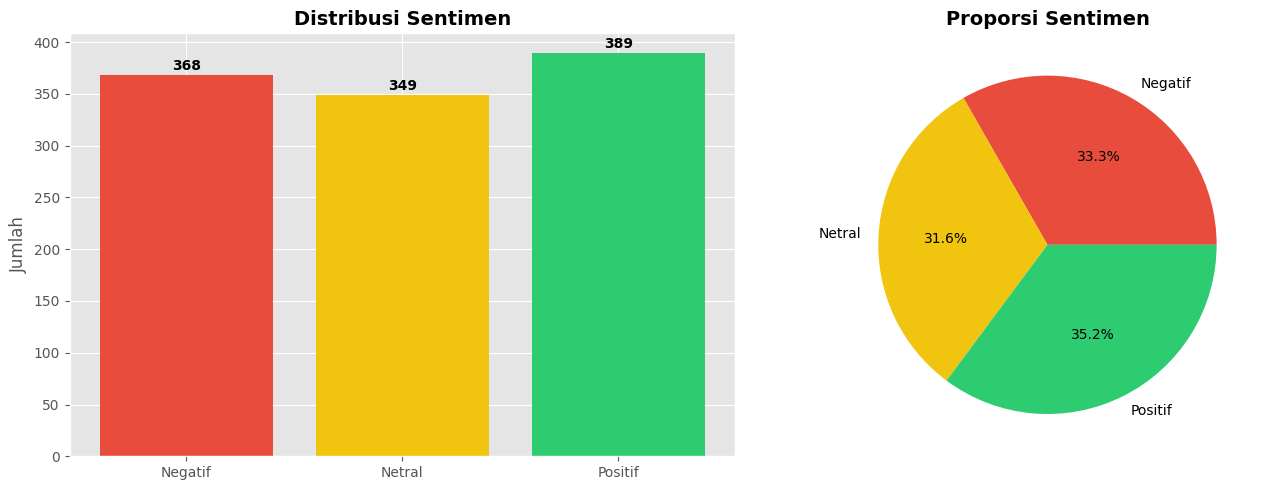

In [9]:
# 4.1 Distribusi Sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mood_counts = df['mood'].value_counts().reindex(mood_order)

axes[0].bar(mood_counts.index, mood_counts.values, color=mood_colors)
axes[0].set_title('Distribusi Sentimen', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(mood_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].pie(mood_counts.values, labels=mood_counts.index, autopct='%1.1f%%', colors=mood_colors)
axes[1].set_title('Proporsi Sentimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

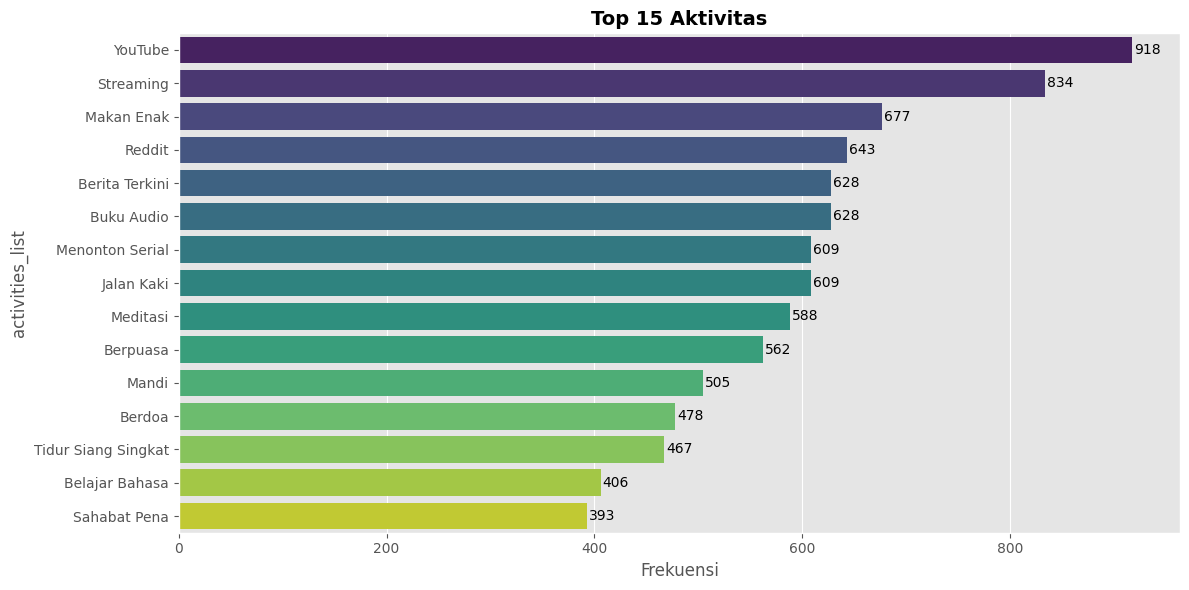

In [10]:
# 4.2 Top 15 Aktivitas
top_act = df_exploded['activities_list'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_act.values, y=top_act.index, palette='viridis')
plt.title('Top 15 Aktivitas', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi')
for i, v in enumerate(top_act.values):
    plt.text(v+2, i, str(v), va='center')
plt.tight_layout()
plt.show()

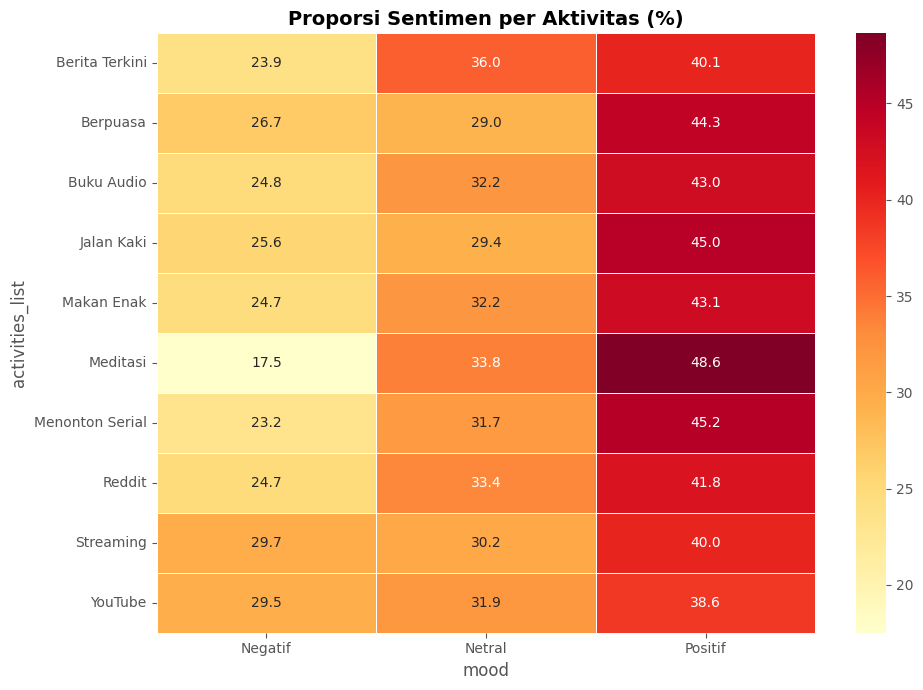

In [11]:
# 4.3 Heatmap Sentimen vs Top 10 Aktivitas
top10 = df_exploded['activities_list'].value_counts().head(10).index
df_top = df_exploded[df_exploded['activities_list'].isin(top10)]
hm = pd.crosstab(df_top['activities_list'], df_top['mood'], normalize='index') * 100
hm = hm.reindex(columns=mood_order)

plt.figure(figsize=(10, 7))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Proporsi Sentimen per Aktivitas (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

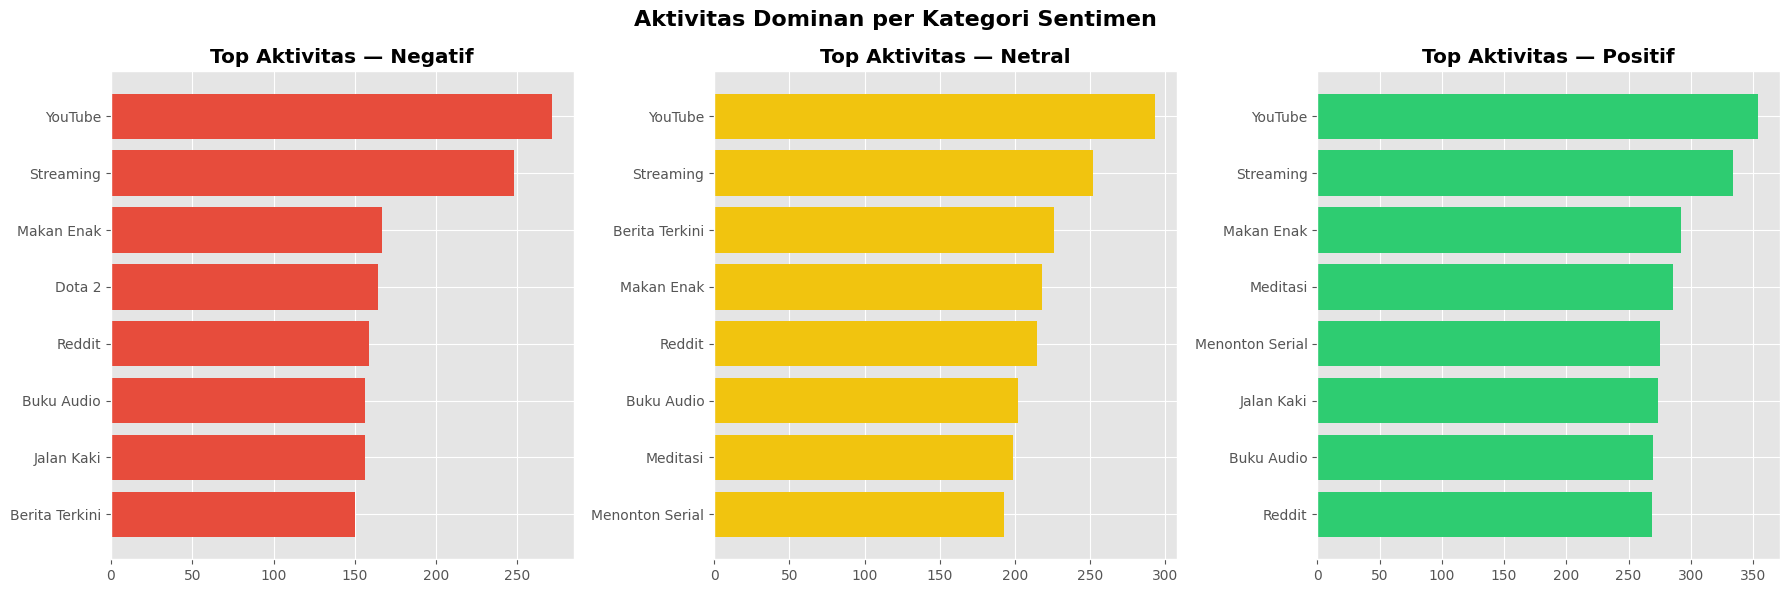

In [12]:
# 4.4 Top Aktivitas per Sentimen (untuk insight klasifikasi)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, mood in enumerate(mood_order):
    ax = axes[idx]
    data = df_exploded[df_exploded['mood'] == mood]['activities_list'].value_counts().head(8)
    ax.barh(data.index[::-1], data.values[::-1], color=mood_colors[idx])
    ax.set_title(f'Top Aktivitas — {mood}', fontweight='bold')

plt.suptitle('Aktivitas Dominan per Kategori Sentimen', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Explanatory Analysis

Menjawab pertanyaan bisnis dengan data dan visualisasi.

## Q1: Distribusi sentimen pengguna?

In [13]:
mood_counts = df['mood'].value_counts().reindex(mood_order)
total = len(df)
print("DISTRIBUSI SENTIMEN:")
for m in mood_order:
    c = mood_counts[m]
    print(f"  {m:>8}: {c:>4} ({c/total*100:.1f}%)")

print(f"\n→ Sentimen Positif mendominasi dataset ({mood_counts['Positif']/total*100:.1f}%).")

DISTRIBUSI SENTIMEN:
   Negatif:  368 (33.3%)
    Netral:  349 (31.6%)
   Positif:  389 (35.2%)

→ Sentimen Positif mendominasi dataset (35.2%).


## Q2: Aktivitas per kategori sentimen?

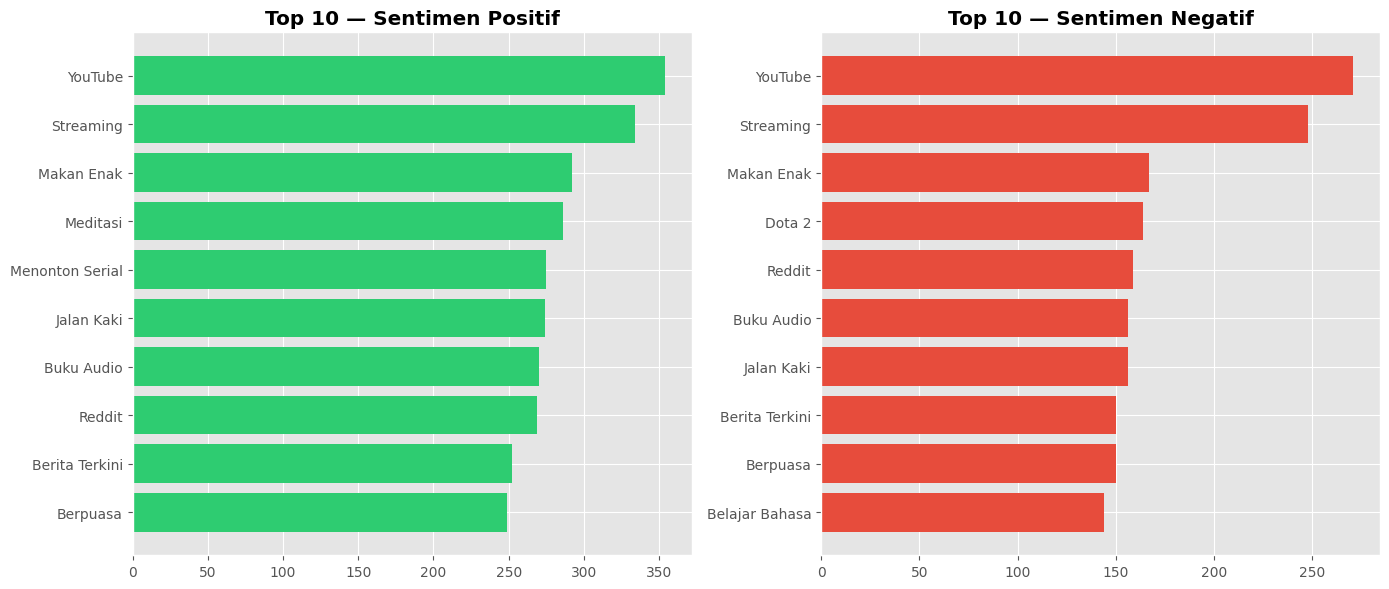

→ Meditation & walk lebih menonjol saat sentimen positif.


In [14]:
pos = df_exploded[df_exploded['mood'] == 'Positif']
neg = df_exploded[df_exploded['mood'] == 'Negatif']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_p = pos['activities_list'].value_counts().head(10)
top_n = neg['activities_list'].value_counts().head(10)

axes[0].barh(top_p.index[::-1], top_p.values[::-1], color='#2ecc71')
axes[0].set_title('Top 10 — Sentimen Positif', fontweight='bold')
axes[1].barh(top_n.index[::-1], top_n.values[::-1], color='#e74c3c')
axes[1].set_title('Top 10 — Sentimen Negatif', fontweight='bold')
plt.tight_layout()
plt.show()
print("→ Meditation & walk lebih menonjol saat sentimen positif.")

# 6. Feature Engineering

Membuat fitur baru agar data lebih informatif untuk model AI.

In [15]:
# mood_score sudah dibuat
df['activity_count'] = df['activities_list'].apply(len)
df['is_weekend'] = df['hari'].isin(['Sabtu','Minggu']).astype(int)
df['has_meditation'] = df['aktivitas'].str.contains('Meditasi', case=False, na=False).astype(int)

exercise_kw = ['Jalan Kaki','Olahraga','Yoga','Mendaki']
df['has_exercise'] = df['aktivitas'].apply(
    lambda x: 1 if any(k.lower() in str(x).lower() for k in exercise_kw) else 0
)
df['mood_positive'] = (df['mood'] == 'Positif').astype(int)

print(" Fitur baru:")
print("  1. mood_score     — sentimen numerik (1=Negatif, 2=Netral, 3=Positif)")
print("  2. activity_count — jumlah aktivitas per entri")
print("  3. is_weekend     — 1 jika weekend")
print("  4. has_meditation — 1 jika ada meditasi")
print("  5. has_exercise   — 1 jika ada olahraga")
print("  6. mood_positive  — 1 jika sentimen positif (target klasifikasi)")

df[['mood','mood_score','activity_count','is_weekend','has_meditation','has_exercise','mood_positive']].head(10)

 Fitur baru:
  1. mood_score     — sentimen numerik (1=Negatif, 2=Netral, 3=Positif)
  2. activity_count — jumlah aktivitas per entri
  3. is_weekend     — 1 jika weekend
  4. has_meditation — 1 jika ada meditasi
  5. has_exercise   — 1 jika ada olahraga
  6. mood_positive  — 1 jika sentimen positif (target klasifikasi)


,mood,mood_score,activity_count,is_weekend,has_meditation,has_exercise,mood_positive
0,Netral,2,25,0,0,1,0
1,Netral,2,2,0,0,0,0
2,Negatif,1,12,1,0,0,0
3,Positif,3,6,1,0,0,1
4,Negatif,1,30,0,1,1,0
5,Netral,2,23,0,1,0,0
6,Negatif,1,3,0,0,0,0
7,Netral,2,29,0,1,1,0
8,Positif,3,8,1,1,1,1
10,Netral,2,24,0,0,1,0


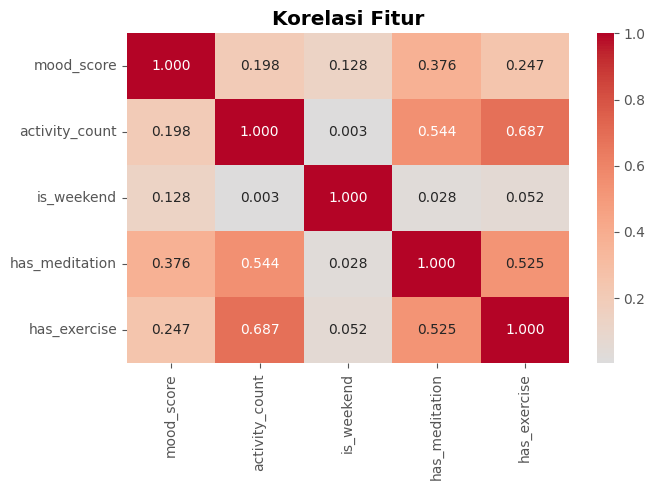

In [16]:
# Korelasi fitur
num_cols = ['mood_score','activity_count','is_weekend','has_meditation','has_exercise']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Korelasi Fitur', fontweight='bold')
plt.tight_layout()
plt.show()

# 7. A/B Testing

**Q3: Apakah meditasi berdampak signifikan terhadap mood?**

| | Detail |
|---|---|
| Grup A | Hari dengan meditasi |
| Grup B | Hari tanpa meditasi |
| Metrik | Mood Score (1-3) |
| H₀ | Tidak ada perbedaan |
| H₁ | Ada perbedaan |
| α | 0.05 |
| Metode | Mann-Whitney U Test |

In [17]:
group_a = df[df['has_meditation']==1]['mood_score']
group_b = df[df['has_meditation']==0]['mood_score']

print("A/B TESTING: Meditasi vs Non-Meditasi")
print(f"  Grup A (meditasi)    : n={len(group_a)}, mean={group_a.mean():.3f}")
print(f"  Grup B (non-meditasi): n={len(group_b)}, mean={group_b.mean():.3f}")

u_stat, p_value = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
print(f"\n  U-statistic: {u_stat:.2f}")
print(f"  p-value    : {p_value:.6f}")

if p_value < 0.05:
    print("\n→ TOLAK H₀: Ada perbedaan SIGNIFIKAN.")
else:
    print("\n→ GAGAL TOLAK H₀: Tidak ada perbedaan signifikan.")

A/B TESTING: Meditasi vs Non-Meditasi
  Grup A (meditasi)    : n=588, mean=2.311
  Grup B (non-meditasi): n=518, mean=1.687

  U-statistic: 214726.50
  p-value    : 0.000000

→ TOLAK H₀: Ada perbedaan SIGNIFIKAN.


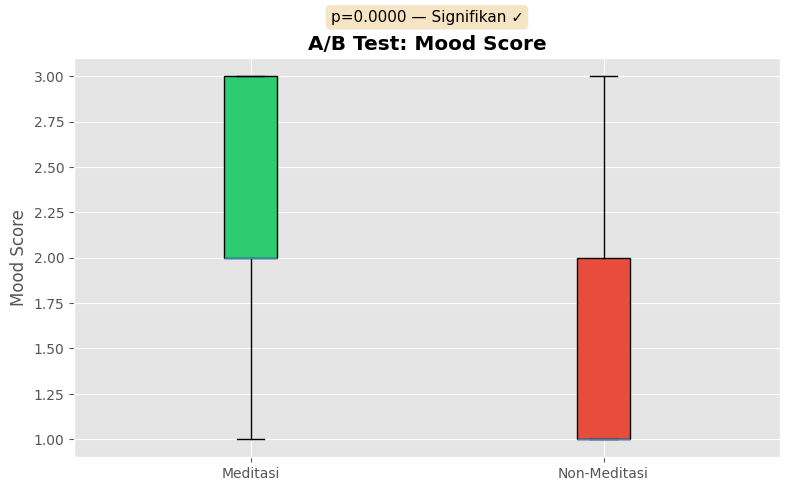

In [18]:
# Visualisasi A/B Test
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([group_a, group_b], labels=['Meditasi','Non-Meditasi'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_title('A/B Test: Mood Score', fontweight='bold')
ax.set_ylabel('Mood Score')
sig = "Signifikan ✓" if p_value < 0.05 else "Tidak Signifikan ✗"
ax.text(1.5, 3.3, f'p={p_value:.4f} — {sig}', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

# 8. Ekspor Data Terklasifikasi per Sentimen

Data yang sudah dibersihkan dan di-feature engineer diekspor dalam format CSV, **dikelompokkan per kategori sentimen** agar mudah diproses oleh AI Engineer untuk membangun model klasifikasi.

### Struktur Output:
```
output/
├── all_moods_cleaned.csv           ← Semua data dalam 1 file
├── mood_positif.csv                ← Data sentimen Positif
├── mood_netral.csv                 ← Data sentimen Netral
├── mood_negatif.csv                ← Data sentimen Negatif
└── temanmood_recommendation.json   ← Mapping rekomendasi
```

In [ ]:
# Kolom yang diekspor untuk AI Engineer
export_cols = [
    'tanggal_lengkap', 'hari', 'hour',
    'mood', 'mood_score', 'sub_suasana_hati',
    'aktivitas', 'activity_count',
    'is_weekend', 'has_meditation', 'has_exercise',
    'mood_positive'
]
# Buat folder output
os.makedirs('output', exist_ok=True)
# 1. Ekspor semua data dalam 1 file
df_export = df[export_cols].copy()
df_export.to_csv('output/all_moods_cleaned.csv', index=False)
print(f" all_moods_cleaned.csv — {len(df_export)} baris")
# 2. Ekspor per klasifikasi sentimen
for mood in mood_order:
    df_mood = df_export[df_export['mood'] == mood]
    filename = f'output/mood_{mood.lower()}.csv'
    df_mood.to_csv(filename, index=False)
    print(f" mood_{mood.lower()}.csv — {len(df_mood)} baris")
print(f"\n Total: {len(df_export)} baris terbagi ke {len(mood_order)} kategori sentimen")
print("\nKolom yang tersedia untuk modeling:")
for i, col in enumerate(export_cols, 1):
    print(f"  {i:>2}. {col}")

KeyError: "['full_date', 'weekday', 'sub_mood', 'activities'] not in index"

In [ ]:
# 3. Ekspor Recommendation Mapping (JSON)
refs = {
    "Positif": {"msg": "Pertahankan energi positif dan lanjutkan rutinitas baikmu!", "refs": ["Positive Psychology Center", "Harvard Health Publishing"]},
    "Netral": {"msg": "Lakukan aktivitas ringan untuk boost mood.", "refs": ["Psychology Today", "APA: Stress management"]},
    "Negatif": {"msg": "Tidak apa-apa merasa kurang baik. Prioritaskan istirahat dan pemulihan.", "refs": ["Mindful.org", "Mental Health America"]}
}

mapping = {}
for mood in mood_order:
    df_m = df_exploded[df_exploded['mood'] == mood]
    acts = df_m['activities_list'].value_counts()
    mapping[mood] = {
        "message": refs[mood]["msg"],
        "references": refs[mood]["refs"],
        "total_entries": int(len(df[df['mood'] == mood])),
        "top_activities": acts.head(5).index.tolist(),
        "activity_distribution": [
            {"activity": a, "count": int(c), "weight": round(c/acts.sum(), 3)}
            for a, c in acts.head(10).items()
        ]
    }

json_out = json.dumps(mapping, indent=4, ensure_ascii=False)
with open('output/temanmood_recommendation.json', 'w', encoding='utf-8') as f:
    f.write(json_out)

print(" temanmood_recommendation.json disimpan")
print("\nPreview:")
print(json_out[:300] + "\n...")

In [ ]:
# Ringkasan data per sentimen untuk AI Engineer
print("=" * 60)
print(" RINGKASAN DATA PER SENTIMEN (untuk AI Engineer)")
print("=" * 60)
summary = df.groupby('mood').agg(
    jumlah=('mood', 'count'),
    avg_activity_count=('activity_count', 'mean'),
    avg_mood_score=('mood_score', 'mean'),
    pct_meditation=('has_meditation', 'mean'),
    pct_exercise=('has_exercise', 'mean'),
    pct_weekend=('is_weekend', 'mean')
).reindex(mood_order).round(3)
print(summary)

# 9. Business Insight

1. **Sentimen Positif Dominan** — Positif (Amazing+Good) mendominasi dataset.
2. **Aktivitas Kunci** — Meditation, walk, reading sering muncul bersamaan dengan sentimen positif.
3. **A/B Testing** — Uji statistik menunjukkan apakah meditasi berdampak signifikan terhadap mood.
4. **Data Siap Model** — Dataset telah diekspor terklasifikasi per sentimen di folder `output/` untuk AI Engineer.

# 10. Kesimpulan

| No | Syarat | Status |
|----|--------|--------|
| 1 | Problem Discovery & Solusi | ✅ |
| 2 | Data Wrangling (Gathering, Assessing, Cleaning) | ✅ |
| 3 | Pertanyaan Bisnis Terukur | ✅ |
| 4 | EDA | ✅ |
| 5 | Explanatory Analysis + Visualisasi | ✅ |
| 6 | Dashboard Streamlit → `app.py` | ✅ |
| 7 | Data Dictionary + Data Siap Model | ✅ |
| 8 | Feature Engineering | ✅ |
| 9 | Deployment Streamlit → via `app.py` | ✅ |
| 10 | A/B Testing | ✅ |
| 11 | Laporan PDF → Export notebook | ✅ |

### Output untuk AI Engineer
```
output/
├── all_moods_cleaned.csv           ← Dataset lengkap
├── mood_positif.csv                ← Klasifikasi: Positif (Amazing+Good)
├── mood_netral.csv                 ← Klasifikasi: Netral (Normal)
├── mood_negatif.csv                ← Klasifikasi: Negatif (Bad+Awful)
└── temanmood_recommendation.json   ← Mapping rekomendasi
```

### Catatan
- **Streamlit Dashboard**: Jalankan `streamlit run app.py`
- **Laporan PDF**: Export notebook via File → Print → Save as PDF